# SRDM Fig. 22 Diagnostic: Current Mismatch

This notebook is a diagnostic for the Fig. 22 screening comparison from Emken, Essig, Xu 2024 (`arXiv:2404.10066`) for silicon, `FDMn=2`, and the DPLM SRDM flux family.

Important status: this notebook currently **does not visually reproduce Fig. 22**. The public DPLM archive is documented as a 1000-sample flux release, while the paper figure used much larger simulation statistics. More importantly, Fig. 22 labels screened curves as `1/|epsilon|^2` using the Lindhard dielectric convention, while this role's implementation currently applies the legacy Thomas-Fermi helper requested for QEDark/QCDark1 SRDM. The resulting screened curves are therefore a regression/diagnostic artifact, not an accepted Fig. 22 validation.

The public `DMeRate.calculate_rates(...)` calls below use MeV masses. The manifest lookup table records the internal eV grid values used to resolve the imported flux files.

Cross-section convention: the DPLM archive grid is indexed by the DM-electron reference cross section `sigma_e_bar`; `sigma_p_bar` is derived in the dark-photon model and is not an independent archive axis.


In [1]:
import gc
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import numericalunits as nu
import torch

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'tests' else Path.cwd()))

from DMeRates.DMeRate import DMeRate
from DMeRates.data.registry import DataRegistry
from DMeRates.srdm.manifest import load_manifest

plt.rcParams.update({
    'figure.figsize': (15, 4),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
})


In [2]:
FIG22_NOMINAL_MASSES_EV = [1.0e4, 1.0e5, 1.0e6]
FIG22_NOMINAL_SIGMA_E_CM2 = 1.0e-35
FDMN = 2
MEDIATOR_SPIN = 'vector'

entries = []
for nominal_mx in FIG22_NOMINAL_MASSES_EV:
    matches = [
        e for e in load_manifest()
        if e.get('grid_family') == 'DPLM'
        and e.get('FDMn') == FDMN
        and e.get('mediator_spin') == MEDIATOR_SPIN
        and e.get('nominal_mX_eV') == nominal_mx
        and e.get('nominal_sigma_e_cm2') == FIG22_NOMINAL_SIGMA_E_CM2
    ]
    if len(matches) != 1:
        raise RuntimeError(f'Expected one Fig. 22 manifest match for nominal mX={nominal_mx:g} eV; found {len(matches)}')
    entry = matches[0]
    flux_path = DataRegistry.srdm_flux_file(entry['filename'])
    if not flux_path.exists():
        raise FileNotFoundError(flux_path)
    entries.append(entry)

for entry in entries:
    print(
        f"nominal mX={entry['nominal_mX_eV']:.6g} eV, "
        f"actual mX={entry['mX_eV']:.10g} eV, "
        f"actual sigma_e={entry['sigma_e_cm2']:.6e} cm^2, "
        f"grid={entry['grid_index']}, file={entry['filename']}, "
        f"sigma convention={entry.get('cross_section_convention', 'sigma_e_bar')}"
    )


nominal mX=10000 eV, actual mX=10000 eV, actual sigma_e=7.906043e-36 cm^2, grid=[24, 0], file=srdm_dphidv_DPLM_row24_col0.txt, sigma convention=sigma_e_bar
nominal mX=100000 eV, actual mX=105929.1998 eV, actual sigma_e=7.906043e-36 cm^2, grid=[24, 12], file=srdm_dphidv_DPLM_row24_col12.txt, sigma convention=sigma_e_bar
nominal mX=1e+06 eV, actual mX=921750.5574 eV, actual sigma_e=7.906043e-36 cm^2, grid=[24, 23], file=srdm_dphidv_DPLM_row24_col23.txt, sigma convention=sigma_e_bar


In [3]:
def run_public_curve(*, backend, entry, do_screen):
    """Return E/eV and dR/dE from the public DMeRate API debug path."""
    dm = DMeRate('Si', form_factor_type=backend)
    result = dm.calculate_rates(
        mX_array=[entry['mX_eV'] / 1.0e6],
        halo_model='srdm',
        FDMn=FDMN,
        ne=[1],
        DoScreen=do_screen,
        sigma_e=entry['sigma_e_cm2'],
        mediator_spin=MEDIATOR_SPIN,
        debug=True,
    )
    _rates, dRdE, _prob = result
    E_eV = (dm.Earr / nu.eV).detach().cpu().numpy()
    dRdE_bare = (dRdE * nu.kg * nu.year * nu.eV).detach().cpu().numpy()
    return E_eV, dRdE_bare


def finite_positive_summary(curves):
    for label, (E, y) in curves.items():
        print(f'{label:18s}: finite={np.all(np.isfinite(y))}, positive bins={np.count_nonzero(y > 0)}, max={np.nanmax(y):.3e}')


In [4]:
all_curves = []

for entry in entries:
    curves = {}
    curve_specs = [
        ('QEDark no TF', 'qedark', False),
        ('QEDark TF', 'qedark', True),
        ('QCDark no TF', 'qcdark', False),
        ('QCDark TF', 'qcdark', True),
    ]
    print('\n---', entry['filename'], '---')
    for label, backend, do_screen in curve_specs:
        E, y = run_public_curve(backend=backend, entry=entry, do_screen=do_screen)
        curves[label] = (E, y)
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    finite_positive_summary(curves)
    all_curves.append((entry, curves))



--- srdm_dphidv_DPLM_row24_col0.txt ---
CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)
CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)
CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)
Using form factor calculated from file: /Users/ansh/Local/SENSEI/DarkMatterRates/form_factors/QCDark/Si_final.hdf5
CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)
Using form factor calculated from file: /Users/ansh/Local/SENSEI/DarkMatterRates/form_factors/QCDark/Si_final.hdf5
QEDark no TF      : finite=True, positive bins=486, max=1.044e+05
QEDark TF         : finite=True, positive bins=486, max=2.742e+07
QCDark no TF      : f

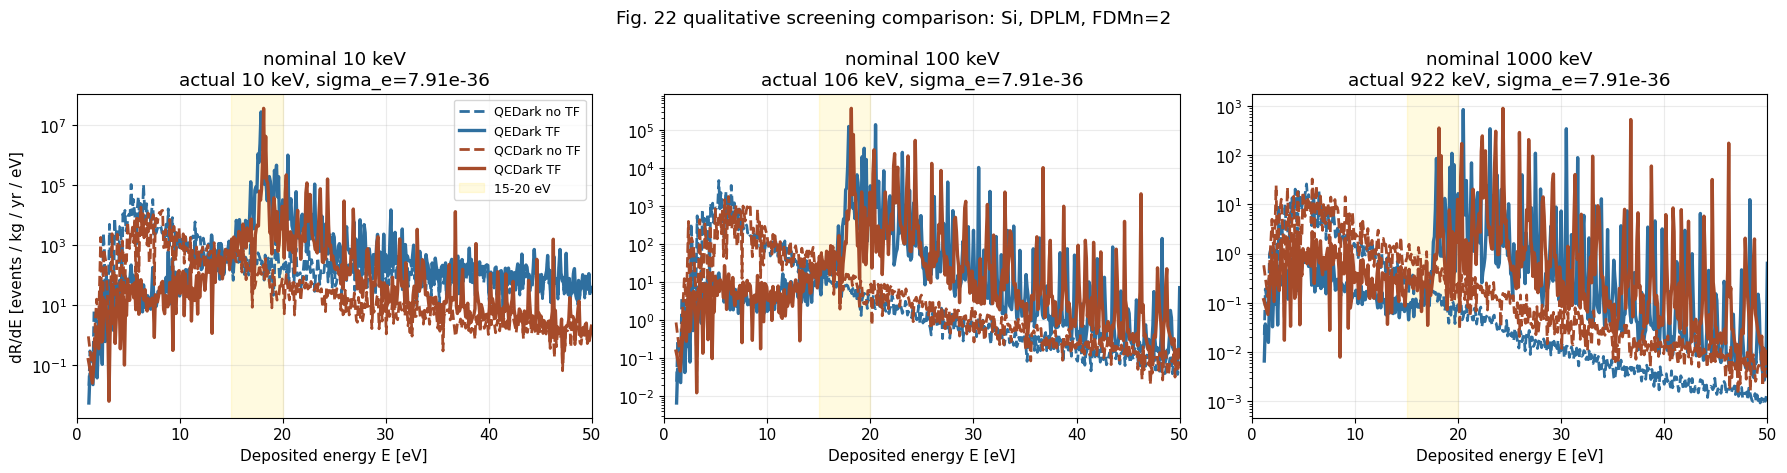

In [5]:
fig, axes = plt.subplots(1, len(all_curves), figsize=(18, 4.8), sharey=False)
if len(all_curves) == 1:
    axes = [axes]

styles = {
    'QEDark no TF': dict(color='#2f6f9f', ls='--', lw=2.0),
    'QEDark TF': dict(color='#2f6f9f', ls='-', lw=2.4),
    'QCDark no TF': dict(color='#a64b2a', ls='--', lw=2.0),
    'QCDark TF': dict(color='#a64b2a', ls='-', lw=2.4),
}

for ax, (entry, curves) in zip(axes, all_curves):
    for label, (E, y) in curves.items():
        mask = (E >= 1.0) & np.isfinite(y) & (y > 0.0)
        ax.plot(E[mask], y[mask], label=label, **styles[label])
    ax.axvspan(15, 20, color='gold', alpha=0.12, label='15-20 eV' if ax is axes[0] else None)
    ax.set_yscale('log')
    ax.set_xlim(0, 50)
    ax.set_xlabel('Deposited energy E [eV]')
    title = (
        f"nominal {entry['nominal_mX_eV']/1e3:g} keV\n"
        f"actual {entry['mX_eV']/1e3:.3g} keV, sigma_e={entry['sigma_e_cm2']:.2e}"
    )
    ax.set_title(title)
axes[0].set_ylabel('dR/dE [events / kg / yr / eV]')
axes[0].legend(loc='best', fontsize=9)
fig.suptitle('Fig. 22 qualitative screening comparison: Si, DPLM, FDMn=2')
fig.tight_layout()
plt.show()


In [6]:
# Mechanical sanity checks only; these are not sufficient for Fig. 22 acceptance.
for entry, curves in all_curves:
    print(f"\nChecks for nominal mX={entry['nominal_mX_eV']:.6g} eV")
    for family in ['QEDark', 'QCDark']:
        E0, y0 = curves[f'{family} no TF']
        E1, y1 = curves[f'{family} TF']
        common = (y0 > 0.0) & (y1 > 0.0) & np.isfinite(y0) & np.isfinite(y1)
        if not np.any(common):
            raise AssertionError(f'{family}: no common positive finite bins')
        differs = not np.allclose(y0[common], y1[common])
        print(f'{family:6s} screened differs from unscreened: {differs}')
        if not differs:
            raise AssertionError(f'{family} screened and unscreened spectra are numerically identical')

    E, qcdark_tf = curves['QCDark TF']
    region = (E >= 15.0) & (E <= 20.0) & np.isfinite(qcdark_tf)
    print(f"QCDark TF 15-20 eV max: {np.max(qcdark_tf[region]):.3e}")

print('NOTE: Mechanical checks passed, but visual Fig. 22 validation is currently NOT accepted.')



Checks for nominal mX=10000 eV
QEDark screened differs from unscreened: True
QCDark screened differs from unscreened: True
QCDark TF 15-20 eV max: 3.601e+07

Checks for nominal mX=100000 eV
QEDark screened differs from unscreened: True
QCDark screened differs from unscreened: True
QCDark TF 15-20 eV max: 3.684e+05

Checks for nominal mX=1e+06 eV
QEDark screened differs from unscreened: True
QCDark screened differs from unscreened: True
QCDark TF 15-20 eV max: 3.550e+02
NOTE: Mechanical checks passed, but visual Fig. 22 validation is currently NOT accepted.
